In [2]:
import numpy as np
import pandas as pd

In [3]:
import os
os.getcwd()
os.listdir()

['.config', 'movies.csv', 'sample_data']

import dataset

In [4]:
df = pd.read_csv('movies.csv')
print

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        250 non-null    object 
 1   year         250 non-null    int64  
 2   rating       250 non-null    float64
 3   votes        250 non-null    object 
 4   runtime      250 non-null    int64  
 5   certificate  250 non-null    object 
 6   genre        250 non-null    object 
 7   gross_total  246 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 15.8+ KB


clean data

In [5]:
df.info()

df['votes'].dtype
df['votes'] = (
    df['votes']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)
df.head()

df['gross_total'] = (
    df['gross_total']
    .astype(str)
    .str.replace('$','', regex=False)
    .str.replace('M','', regex=False)
    .astype(float)
)
df = df.dropna(subset=['gross_total'])

df.info()
df.head()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        250 non-null    object 
 1   year         250 non-null    int64  
 2   rating       250 non-null    float64
 3   votes        250 non-null    object 
 4   runtime      250 non-null    int64  
 5   certificate  250 non-null    object 
 6   genre        250 non-null    object 
 7   gross_total  246 non-null    object 
dtypes: float64(1), int64(2), object(5)
memory usage: 15.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 249
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        246 non-null    object 
 1   year         246 non-null    int64  
 2   rating       246 non-null    float64
 3   votes        246 non-null    int64  
 4   runtime      246 non-null    int64  
 5   certificate  24

,title,year,rating,votes,runtime,certificate,genre,gross_total
0,The Shawshank Redemption,1994,9.3,3168010,142,R,Drama,29.33
1,The Godfather,1972,9.2,2212884,175,R,"Crime, Drama",250.93
2,The Dark Knight,2008,9.1,3145646,152,PG-13,"Action, Crime, Drama",1008.48
3,The Godfather Part II,1974,9.0,1486878,202,R,"Crime, Drama",48.20
4,12 Angry Men,1957,9.0,977359,96,Unrated,"Crime, Drama",0.01


see how the plot is

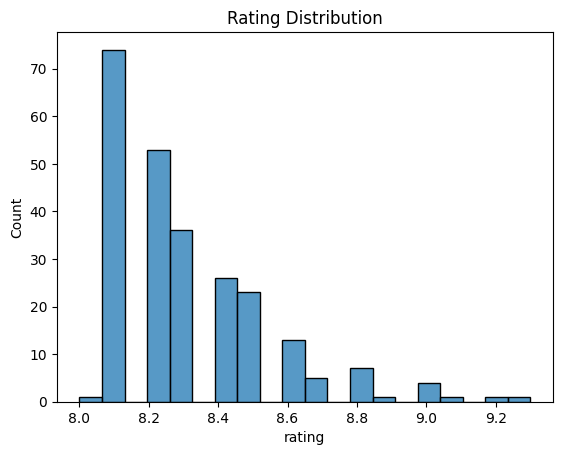

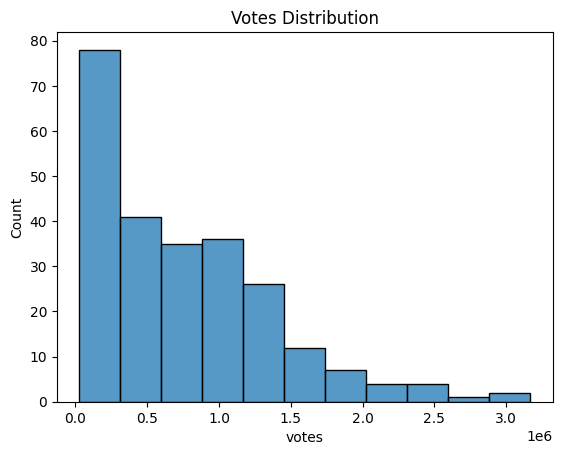

Correlation: 0.594759903247353
P-Value 6.310039105553835e-25


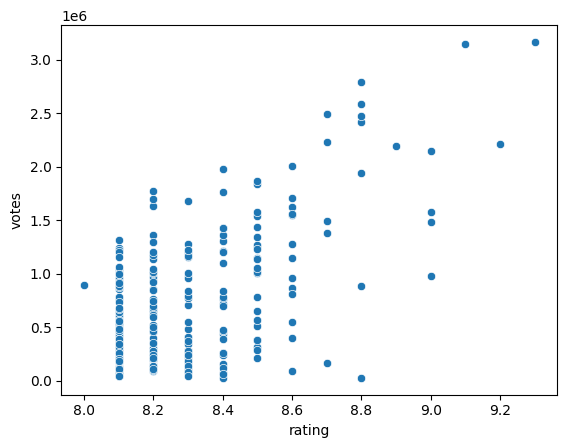

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# how rating effect the plot
sns.histplot(df['rating'], bins=20)
plt.title('Rating Distribution')
plt.show()

# how votes effect the plot
sns.histplot(df['votes'])
plt.title('Votes Distribution')
plt.show()

# rating vs. votes
sns.scatterplot(data=df, x='rating', y='votes')

from scipy.stats import pearsonr
corr, p_value = pearsonr(df['rating'], df['votes'])

print("Correlation:", corr)
print("P-Value", p_value)

how gross total effect

/tmp/ipykernel_3526/4071472069.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


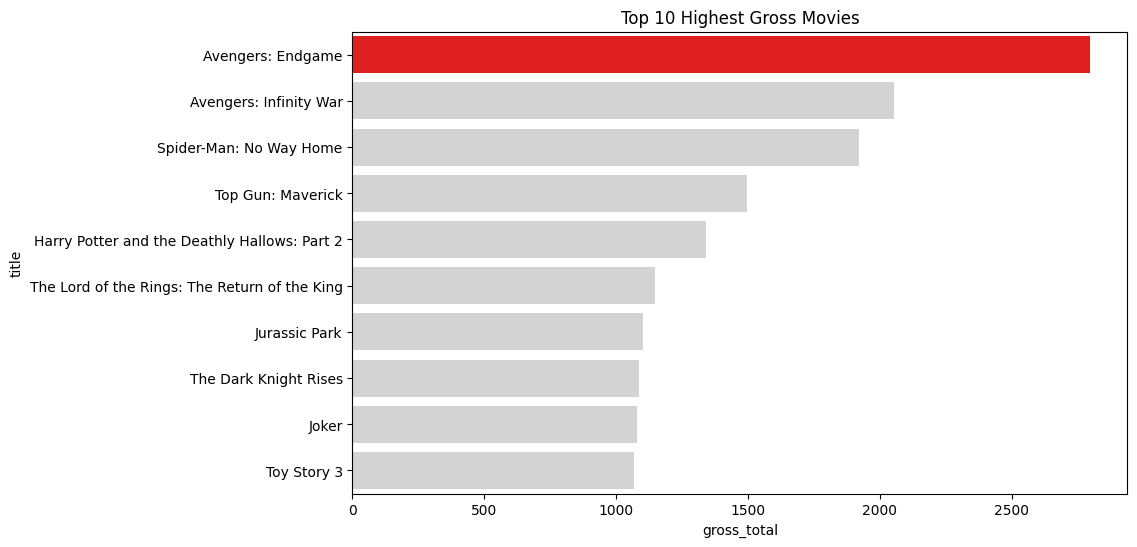

In [26]:
top_gross = df.sort_values('gross_total', ascending=False).head(10)
top_gross

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_gross,
    x='gross_total',
    y='title',
    palette = ['red'] + ['lightgray'] * (len(top_gross) - 1)
)

plt.title('Top 10 Highest Gross Movies')

plt.show()

**Are those high-gross total movies also highly popular?**
Due to the correlation (0.49) and P-Value (2.555043111383153e-16), indicating that there is a moderate correlation between votes and gross total, suggesting that higher-grossing movies tend to attract more audience engagement.

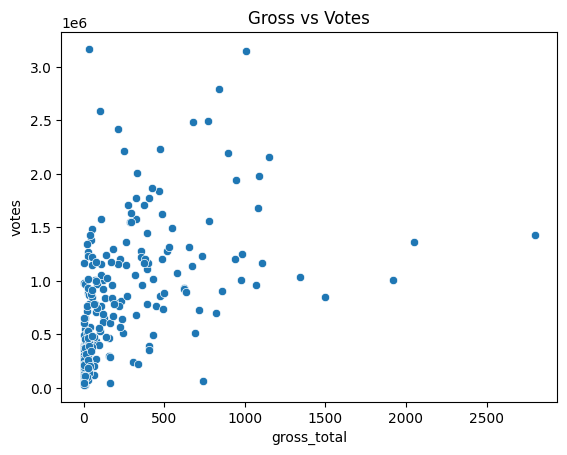

Correlation: 0.4908237749131975
P-value: 2.555043111383153e-16


In [8]:
sns.scatterplot(data=df, x='gross_total', y='votes')

plt.title('Gross vs Votes')
plt.show()

# Now we want to see how these 2 variables are relevant?
df[['gross_total','votes']].isna().sum()

from scipy.stats import pearsonr

corr, p_value = pearsonr(df['gross_total'], df['votes'])

print("Correlation:", corr)
print("P-value:", p_value)

Dealing with genre data

In [9]:
genre_dummies = df['genre'].str.get_dummies(sep=', ')
df = pd.concat([df, genre_dummies], axis=1)

df.head()



,title,year,rating,votes,runtime,certificate,genre,gross_total,Action,Adventure,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,The Shawshank Redemption,1994,9.3,3168010,142,R,Drama,29.33,0,0,...,0,0,0,0,0,0,0,0,0,0
1,The Godfather,1972,9.2,2212884,175,R,"Crime, Drama",250.93,0,0,...,0,0,0,0,0,0,0,0,0,0
2,The Dark Knight,2008,9.1,3145646,152,PG-13,"Action, Crime, Drama",1008.48,1,0,...,0,0,0,0,0,0,0,0,0,0
3,The Godfather Part II,1974,9.0,1486878,202,R,"Crime, Drama",48.20,0,0,...,0,0,0,0,0,0,0,0,0,0
4,12 Angry Men,1957,9.0,977359,96,Unrated,"Crime, Drama",0.01,0,0,...,0,0,0,0,0,0,0,0,0,0


Knowing which genre is popular

In [10]:
genre_columns = genre_dummies.columns

df[genre_columns].corrwith(df['votes']).sort_values(ascending=False)

,0
Sci-Fi,0.248978
Crime,0.183332
Adventure,0.160807
Action,0.155129
Fantasy,0.152484
Horror,0.045683
Thriller,0.017401
Western,-0.023109
Music,-0.040122
Animation,-0.042826


**Now we aim to identify genre combinations that are both frequently occurring and highly popular.**

From the analysis, Drama appears most frequently across top movies.
Moreover, combinations such as Adventure + Drama + Sci-Fi and Action + Sci-Fi demonstrate high average votes, indicating strong audience engagement.

Therefore, Drama-centered and Sci-Fi-related combinations appear to be the most promising genres for streaming platforms to prioritize.

,count,avg_votes
genre,,
"Action, Adventure",2,983123.0
"Action, Adventure, Comedy",1,105801.0
"Action, Adventure, Drama",2,1280019.0
"Action, Adventure, Fantasy",5,1317210.2
"Action, Adventure, Horror",1,837039.0


/tmp/ipykernel_3526/3509026591.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


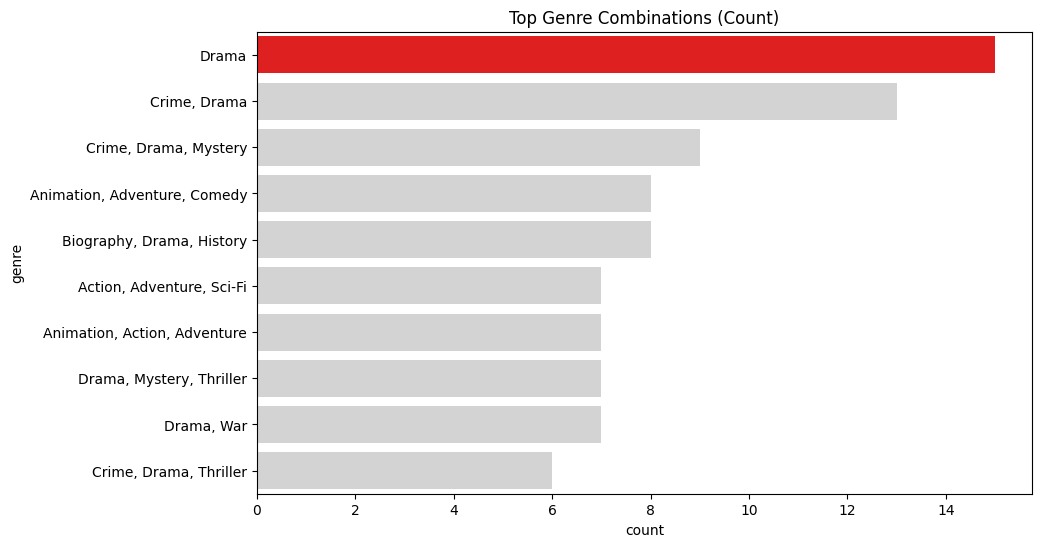

/tmp/ipykernel_3526/3509026591.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


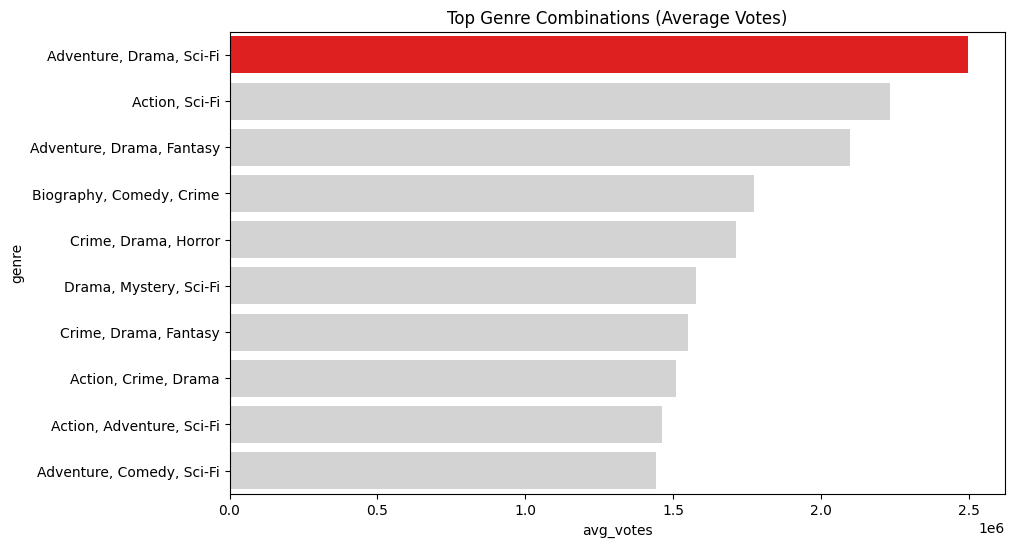

In [11]:
# Group data by genre and calculate count and average votes
genre_analysis = df.groupby('genre').agg(
    count=('title', 'count'),
    avg_votes=('votes', 'mean')
)

display(genre_analysis.head())

# top genre count rating
top_genre_count = genre_analysis.sort_values(
    by='count',
    ascending=False
).head(10)

colors_count = ['red'] + ['lightgray'] * (len(top_genre_count)-1)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genre_count['count'],
    y=top_genre_count.index,
    palette=colors_count
)

plt.title('Top Genre Combinations (Count)')
plt.show()


# average votes rating
top_genre_votes = genre_analysis.sort_values(
    by='avg_votes',
    ascending=False
).head(10)

colors_votes = ['red'] + ['lightgray'] * (len(top_genre_count)-1)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_genre_votes['avg_votes'],
    y=top_genre_votes.index,
    palette=colors_count

)

plt.title('Top Genre Combinations (Average Votes)')
plt.show()

See which variable effects the most?



















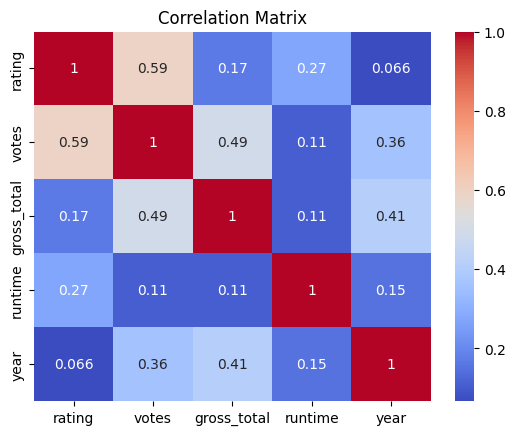

,votes
rating,0.59
gross_total,0.49
year,0.36
runtime,0.11


In [12]:
corr = df[['rating','votes','gross_total','runtime','year']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Now we want to see the rank of the variables
corr['votes'].drop('votes').sort_values(ascending=False).round(2)



**Then, we need to create a scoring formula to recommend top 100 most popular movies to the audience.**

The formula combines normalized variables including rating, gross total, release year, and genre popularity to generate a recommendation score for each movie.

Movies such as Avengers: Endgame, The Dark Knight, Avengers: Infinity War, The Lord of the Rings: The Return of the King, and Inception rank among the top positions.

These results suggest that movies wigh higher audience ratings, larger gross total, and popular genres like Action, Adventure, Sci-Fi, and Drama are more likely to attract viewers on streaming platforms.

Therefore, streaming platform should priortize acquiring high-rated blockbuster films in popular genres to maximize audience engagement and viewing time.

In [24]:
# But first, we need to normalize the data across all variables.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['rating_norm', 'gross_norm', 'year_norm', 'votes_norm']] = scaler.fit_transform(
    df[['rating', 'gross_total', 'year', 'votes']]
)

# Choose important genres based on previous analysis
important_genres = ['Sci-Fi', 'Crime', 'Adventure', 'Action', 'Fantasy']

# Create genre score
df['genre_score'] = df[important_genres].sum(axis=1)
df['genre_score_norm'] = scaler.fit_transform(df[['genre_score']])

# Build recommendation score
df['recommend_score'] = (
    df['rating_norm'] * 0.35 +
    df['gross_norm'] * 0.25 +
    df['year_norm'] * 0.20 +
    df['genre_score_norm'] * 0.20
)

# Rank all movies
recommendation_movies = df.sort_values('recommend_score', ascending=False).head(100)
recommendation_movies

,title,year,rating,votes,runtime,certificate,genre,gross_total,Action,Adventure,...,Thriller,War,Western,rating_norm,gross_norm,year_norm,votes_norm,genre_score,genre_score_norm,recommend_score
73,Avengers: Endgame,2019,8.4,1432148,181,PG-13,"Action, Adventure, Sci-Fi",2799.44,1,1,...,0,0,0,0.307692,1.000000,0.942308,0.447213,3,1.000000,0.746154
2,The Dark Knight,2008,9.1,3145646,152,PG-13,"Action, Crime, Drama",1008.48,1,0,...,0,0,0,0.846154,0.360243,0.836538,0.992878,2,0.666667,0.686856
60,Avengers: Infinity War,2018,8.4,1359383,149,PG-13,"Action, Adventure, Sci-Fi",2052.42,1,1,...,0,0,0,0.307692,0.733154,0.932692,0.424041,3,1.000000,0.677519
5,The Lord of the Rings: The Return of the King,2003,9.0,2152126,201,PG-13,"Adventure, Drama, Fantasy",1148.97,0,1,...,0,0,0,0.769231,0.410429,0.788462,0.676491,2,0.666667,0.662864
13,Inception,2010,8.8,2796318,148,PG-13,"Action, Adventure, Sci-Fi",839.79,1,1,...,0,0,0,0.615385,0.299985,0.855769,0.881634,3,1.000000,0.661535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,No Country for Old Men,2007,8.2,1179896,122,R,"Crime, Drama, Thriller",171.64,0,0,...,1,0,0,0.153846,0.061312,0.826923,0.366883,1,0.333333,0.301226
86,Capharnaüm,2018,8.4,123170,126,R,Drama,64.42,0,0,...,0,0,0,0.307692,0.023012,0.932692,0.030367,0,0.000000,0.299984
199,"Monsters, Inc.",2001,8.1,1068117,92,G,"Animation, Adventure, Comedy",579.77,0,1,...,0,0,0,0.076923,0.207102,0.769231,0.331287,1,0.333333,0.299211
22,Shichinin no samurai,1956,8.6,400179,207,Unrated,"Action, Drama",1.09,1,0,...,0,0,0,0.461538,0.000389,0.336538,0.118581,1,0.333333,0.295610


***SOLUTION***

**Insights and findings**

The recommended movies generally have high ratings (average 8.45), strong audience engagement (average 1.2 million votes), and solid box office performance (average $470 million). Additionally, most recommended movies are relatively recent releases.

In terms of genres, Action and Adventure appear most frequently, often combined with Sci-Fi or Animation. This suggests that high-engagement genres such as Action, Adventure, Sci-Fi, and Animation are more likely to attract viewers on streaming platforms.

Therefore, streaming platforms should prioritize acquiring high-rated, high-grossing, and recent movies within these popular genre combinations.


In [21]:
recommendation_movies[['rating','votes','gross_total','year']].describe()


,rating,votes,gross_total,year
count,100.000000,1.000000e+02,100.000000,100.000000
mean,8.445000,1.205687e+06,470.333200,2003.010000
std,0.277206,6.675063e+05,476.810367,15.191368
min,8.000000,3.014100e+04,0.010000,1956.000000
25%,8.200000,8.298455e+05,109.637500,1994.750000
50%,8.400000,1.158706e+06,378.020000,2004.000000
75%,8.600000,1.554083e+06,681.377500,2014.250000
max,9.300000,3.168010e+06,2799.440000,2025.000000


In [22]:
recommendation_movies['genre'].value_counts().head(10)

,count
genre,
"Action, Adventure, Sci-Fi",7
"Animation, Action, Adventure",7
"Animation, Adventure, Comedy",7
"Crime, Drama",6
"Action, Crime, Drama",6
"Action, Adventure, Fantasy",5
"Crime, Drama, Thriller",4
"Animation, Adventure, Family",4
"Adventure, Drama, Fantasy",3


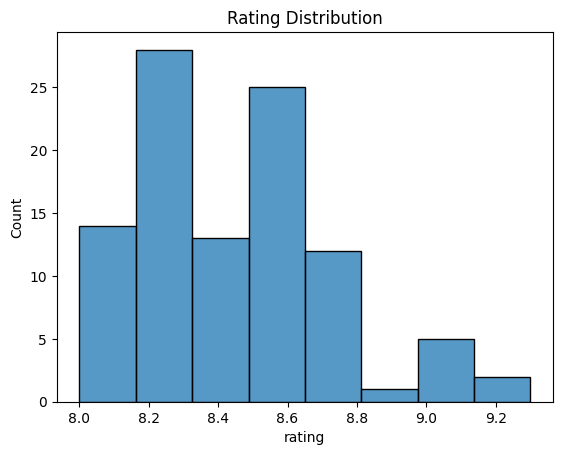

In [23]:
sns.histplot(recommendation_movies['rating'])
plt.title('Rating Distribution')
plt.show()